# nuScenes Dataset Tutorial

**Objectives**
- Visualize camera images and object label
- Visualize camera iamges and map label

In [50]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

%matplotlib inline

## Initialize

Initialize dataset and pick a sample

In [51]:
DATASET_PATH = '/mnt/dataset/nuscenes/v1.0-mini'

nusc = NuScenes(version='v1.0-mini', dataroot=DATASET_PATH, verbose=True)
sample = nusc.sample[0]

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.264 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


## Configuration

In [73]:
L = 80
fig = plt.figure(figsize=(9, 15))

<Figure size 900x1500 with 0 Axes>

## Visualize Camera Images

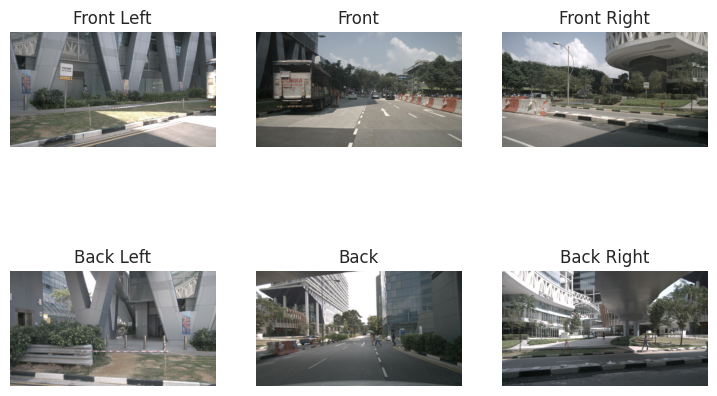

In [74]:
camera_order = [
    'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT'
]

camera_images = []
for cam in camera_order:
    data = nusc.get('sample_data', sample['data'][cam])
    img = cv2.imread(nusc.dataroot + '/' + data['filename'])
    camera_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

for i, img in enumerate(camera_images):
    ax = fig.add_subplot(5, 3, i+1)
    ax.imshow(img)
    ax.set_title(camera_order[i].replace("CAM_", "").replace("_", " ").title())
    ax.axis('off')

fig

## Visualize BEV 

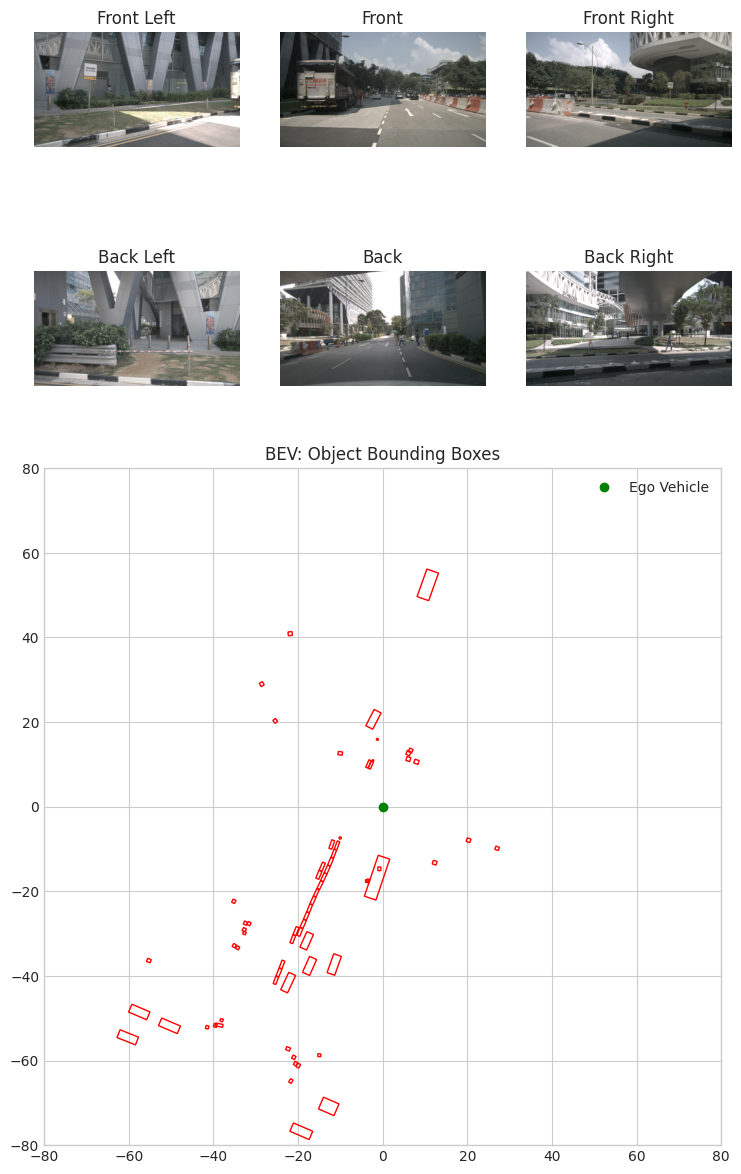

In [75]:
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(5, 3, figure=fig)
ax_bev = fig.add_subplot(gs[2:, :])  # 전체 2행을 사용하여 4번째 열에 BEV

# ax_bev = fig.add_subplot(1, 2, 2)
ax_bev.set_title('BEV: Object Bounding Boxes')
ax_bev.set_xlim(-L, L)
ax_bev.set_ylim(-L, L)
ax_bev.set_aspect('equal')

# Ego pose
ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
ego_translation = np.array(ego_pose['translation'][0:2])

# Object bounding box
ann_tokens = sample['anns']
for token in ann_tokens:
    ann = nusc.get('sample_annotation', token)
    box = Box(ann['translation'], ann['size'], Quaternion(ann['rotation']))
    center = np.array(box.center[:2]) - ego_translation
    corners = box.bottom_corners()[:2] - ego_translation.reshape(2, 1)
    rect = plt.Polygon(corners.T, fill=False, edgecolor='red')
    ax_bev.add_patch(rect)

ax_bev.plot(0, 0, 'go', label='Ego Vehicle')
ax_bev.legend()

fig
# plt.tight_layout()
# plt.show()

## Visualize Map Label

Adding ego poses to map...


100%|██████████| 1/1 [00:00<00:00, 6775.94it/s]

Creating plot...



/usr/local/lib/python3.8/dist-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/usr/local/lib/python3.8/dist-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


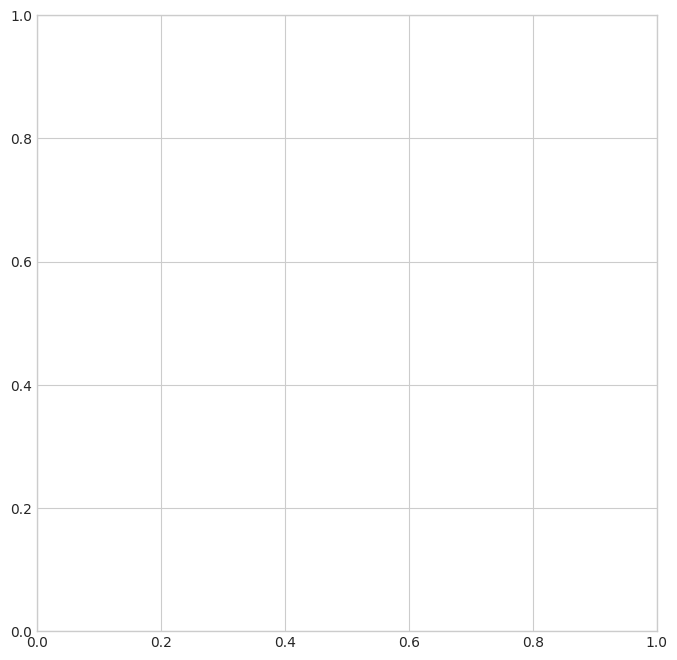

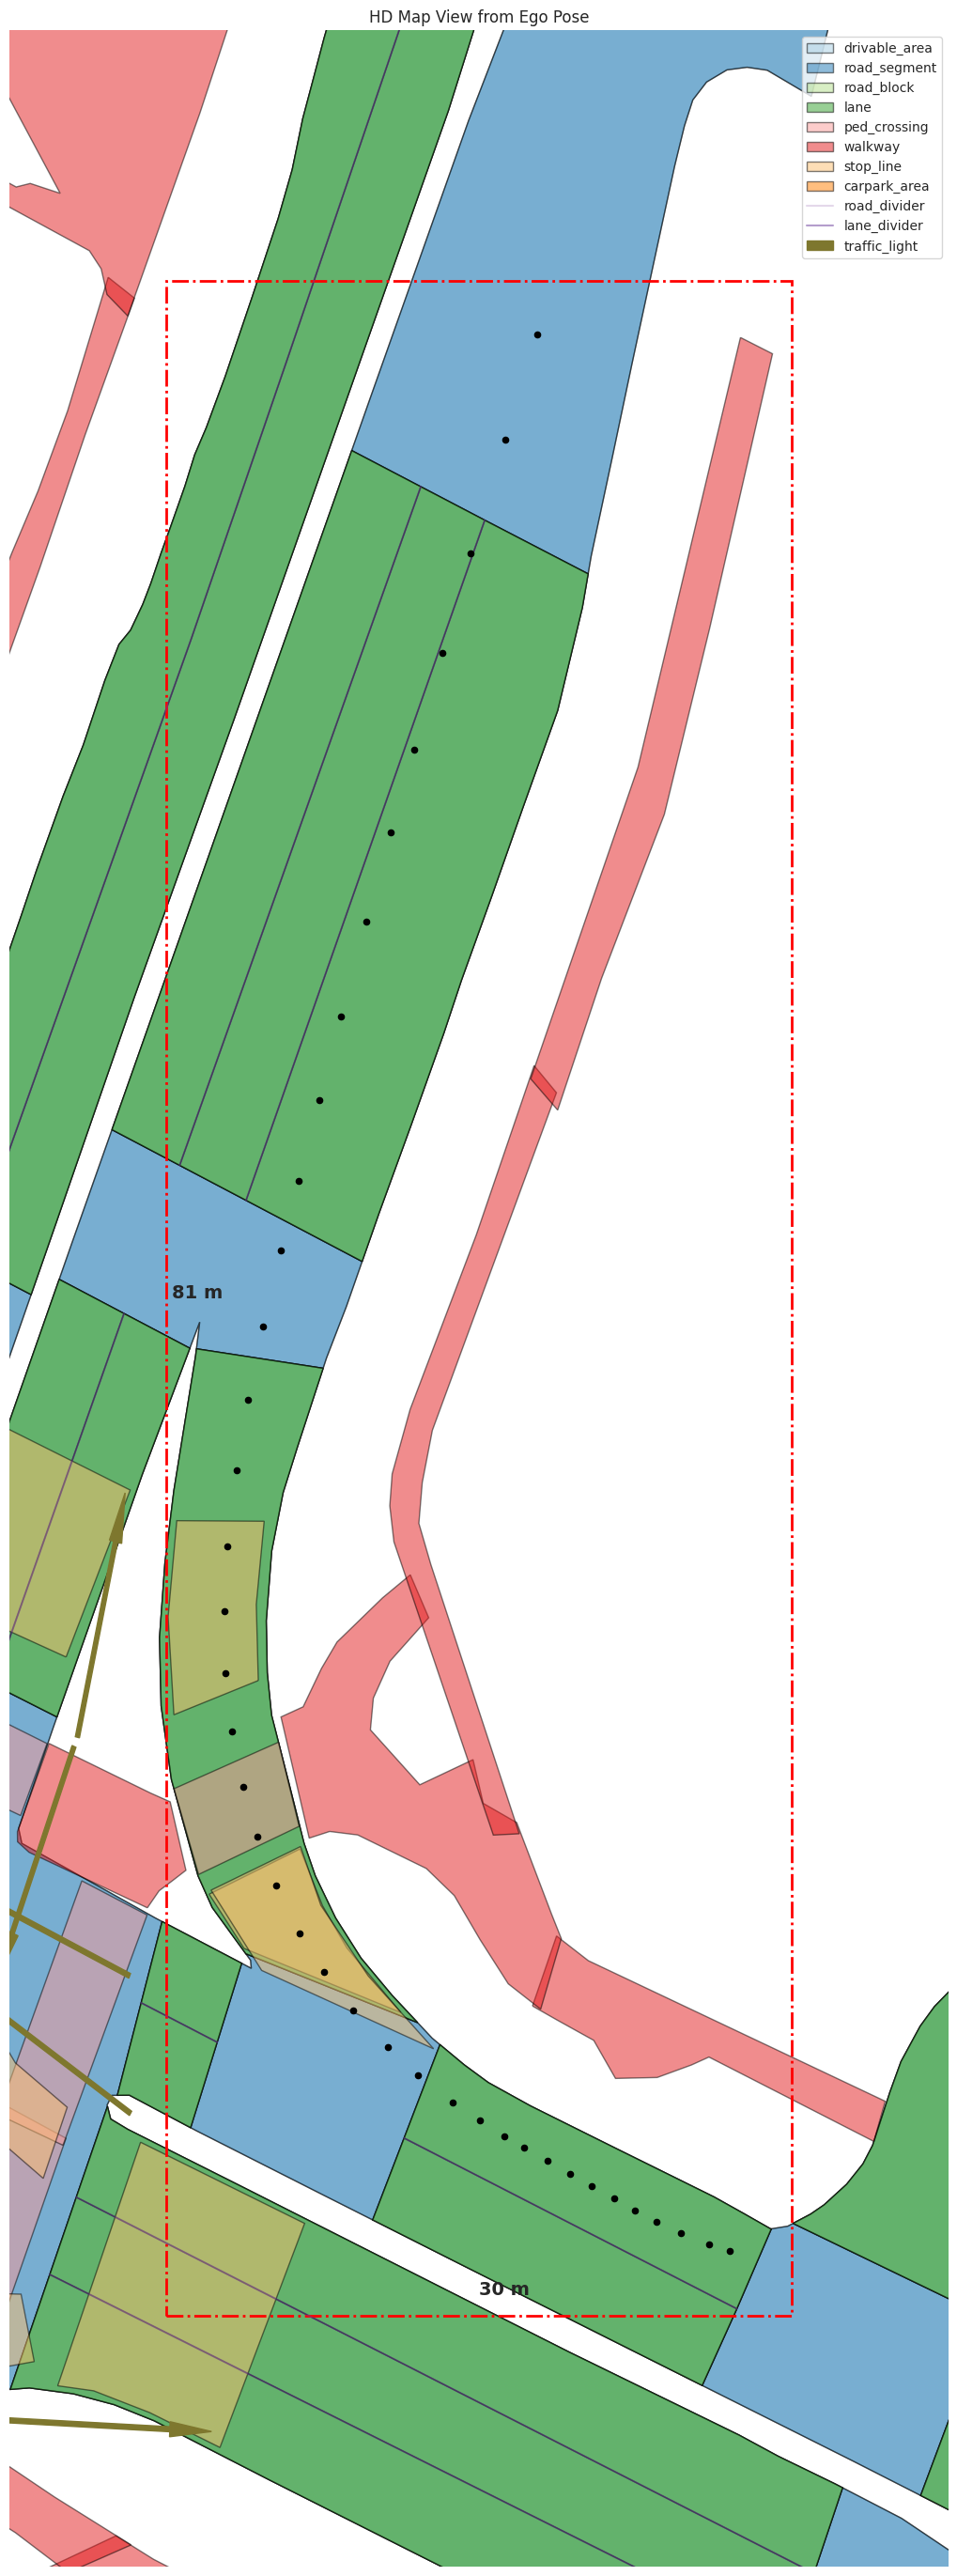

In [56]:
from nuscenes.map_expansion.map_api import NuScenesMap
from shapely.geometry import Polygon

scene = nusc.get('scene', nusc.sample[0]['scene_token'])
log = nusc.get('log', scene['log_token'])
location = log['location']  # e.g., 'boston-seaport'
nusc_map = NuScenesMap(dataroot=nusc.dataroot, map_name=location)

# 중심 좌표
pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['CAM_FRONT'])['ego_pose_token'])
ego_x, ego_y = pose['translation'][0:2]

# BEV 이미지 그리기
fig, ax = plt.subplots(figsize=(8, 8))
nusc_map.render_egoposes_on_fancy_map(nusc, scene_tokens=[scene['token']])
plt.title("HD Map View from Ego Pose")
plt.axis('off')
plt.show()